# CME futures: capacity, loss function, and when to stop adding trees

[`06_linear`](06_linear.ipynb) fitted a penalty grid to these 69 features and found almost
nothing above zero at the five-day horizon the strategy chapters trade. A linear model can only
represent a relationship it is given
in the right shape: it sees an interaction between carry and momentum only because someone
multiplied those columns together and named the product. Gradient boosting has no such
restriction. It builds a sequence of shallow trees, each fitted to what the ones before it got
wrong, and a tree splits on one feature inside a region defined by others - so an interaction is
something it can find rather than something it must be handed.

That freedom is the whole question. A model that can represent anything can also fit noise, and
with 30 products and 69 features there is plenty to fit. Three dials control how far it goes,
and this notebook varies all three:

- **Capacity**, set by `num_leaves`: how many regions one tree may carve the feature space into.
  Seven leaves can express a handful of conditions; 63 can express a fine partition that may
  describe the training window and nothing beyond it.
- **The loss function**, which decides what "got wrong" means. This matters more here than in an
  equity universe. Commodity returns are heavy-tailed, and squared error weights an observation
  by the square of its error, so a single extreme move can carry hundreds of times the weight of
  a typical one. Absolute error and Huber loss do not, which makes the comparison between the
  three objectives a comparison of how much the tails are allowed to steer the fit.
- **When to stop**, set by the number of trees. Unlike a linear fit, a boosted model has a
  meaningful state at every iteration, so this notebook scores each configuration at ten points
  along its own training run rather than only at the end.

The third dial is the one that changes how results must be read. **A checkpoint is part of a
configuration, not a detail of how it was fitted.** Scoring 15 declared configurations at ten
checkpoints each produces 150 candidate models per label, 300 across the two the case study
declares, and treating that as 15 candidates while quietly keeping each one's best iteration
would be reporting the maximum of ten numbers as though it were one.

**Learning objectives.** By the end of this notebook you will be able to:

- Read a declared gradient boosting grid and say what each configuration varies.
- Explain why a boosted model produces one result per checkpoint while a linear model produces
  one result in total, and what that implies for counting candidates.
- Read a learning curve of out-of-sample information coefficient against tree count, and tell
  apart a model still learning from one that has begun fitting the training window.
- Say why the choice of loss function is a statement about the label's tails, and relate that to
  what a rank-based metric rewards.
- Recognise that picking each configuration's best checkpoint after seeing the results is a
  selection decision, and locate where selection is actually made.
- Compare the same grid across two prediction horizons and say what a reversal between them
  rules out.

**Book reference**: Chapter 12, Section 12.2 (GBM libraries) and Section 12.3 (how to tune a
boosted model). Chapter 6, Section 6.7 (Search accounting and run logging) introduces the run
log this notebook writes to.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`06_linear`](06_linear.ipynb) fitted the linear population this one is compared against.

**What it writes**: one training run per configuration and one complete validation prediction
set per configuration and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a named population.
[`13_backtest`](13_backtest.ipynb) reads that population and selects on validation backtest
Sharpe. **Selection happens there, not here.**

In [1]:
"""Fit the declared CME futures gradient boosting population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from case_studies.cme_futures.research_workflow import supersedes_declaration
from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    narrows_declared_catalog,
    open_study,
    population_supersedes,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
CONFIG_NAMES: list[str] = []
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = "9f26b89f9310"

In [3]:
study = open_study("cme_futures", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)

## 1. Which labels, and which models

The labels are the same two the linear notebook fitted: `fwd_ret_5d`, the total return over the
five trading days after the decision date, and `fwd_ret_21d` over 21 days. Keeping the set fixed
is what makes the two populations comparable - the families differ, the targets do not. It also
carries the horizon question forward: `06_linear` found the 21-day label reaching fifteen times
what the traded five-day label reached, and a grid fitted on one label could not say whether
that is a property of the horizon or of the linear family. `LABELS` restricts the run to a
subset when you want one, and defaults to everything the menus declare.

In [4]:
declared_labels(study, "gbm")

('fwd_ret_21d', 'fwd_ret_5d')

Each label's menu at `config/training/{label}.yaml` lists 15 named configurations under `gbm:`,
and each resolves to a preset in `case_studies/config/lgb/`. The two menus declare the same
fifteen, so the grid is fitted twice over, once per horizon. The grid is a product of two axes:

- **Five capacity profiles.** `default` uses the library's own leaf count; the rest fix it at 7,
  15, 31 and 63. Leaf count is the direct control on how finely one tree may partition the
  feature space, and it is the dial that decides whether sector-specific behaviour can be
  expressed at all.
- **Three objectives.** `mse` minimizes squared error, `mae` absolute error, and `huber` behaves
  like squared error for small residuals and like absolute error beyond a threshold derived from
  each fold's own label spread.

Every configuration runs the same number of boosting iterations with the same learning rate, so
the grid isolates capacity and loss rather than confounding them with training length.

In [5]:
configs = load_model_configs(
    study,
    "gbm",
    labels=LABELS or None,
    config_names=CONFIG_NAMES or None,
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""gbm""","""fwd_ret_21d""","""default_mse""","""""","""objective=regression, seed=42"""
"""gbm""","""fwd_ret_21d""","""default_mae""","""""","""objective=regression_l1, seed=…"
"""gbm""","""fwd_ret_21d""","""default_huber""","""""","""objective=huber, seed=42"""
"""gbm""","""fwd_ret_21d""","""leaves_7_mse""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_21d""","""leaves_7_mae""","""""","""bagging_fraction=0.8, bagging_…"
…,…,…,…,…
"""gbm""","""fwd_ret_5d""","""leaves_31_mae""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_31_huber""","""""","""bagging_fraction=0.8, bagging_…"
"""gbm""","""fwd_ret_5d""","""leaves_63_mse""","""""","""bagging_fraction=0.8, bagging_…"


`LABELS` and `CONFIG_NAMES` both narrow what is fitted, and a narrowed run declares a different
set of members than the canonical population does. A population is immutable once written, so
such a run must publish under its own name. Comparing the loaded rows against the complete
declared catalog catches either knob, and says so here rather than several cells later in a
message about hashes.

In [6]:
if narrows_declared_catalog(study, "gbm", configs) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs, which is not the "
        "complete declared catalog, so it cannot publish the canonical population; pass "
        "POPULATION_NAME to give it its own"
    )

## 2. Binding the declarations to the data

Resolving reads the label and feature files, computes the fold boundaries, works out the exact
rows each fit must predict, and turns any data-dependent parameter into the number it will use.
Huber's threshold is one of those: it is a fraction of the training labels' standard deviation,
so it is a different number on every fold and is resolved from that fold's own data.

Nothing is fitted here, so the plan can be inspected first. Four things to check:

**Read the checks within a label, not across the whole frame.** Each label has its own purge
buffer in `config/setup.yaml` - `5D` for the primary and `21D` for the variant - so the two
horizons resolve to different fold boundaries and different eligible samples, and `label` is the
first column for that reason.

- **`feature_count`, `eligible_entities` and `eligible_rows` agree across every row of the same
  label.** A row that differs from its own label's neighbours is a configuration measured on a
  different sample from theirs. Between labels they differ by construction.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits. This one
  does hold across labels.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out tail visible. `validation_end` falls earlier for the 21-day label, because a longer
  forward window has to stop earlier to keep its outcome inside the development period.
- **`checkpoints` is where this differs from the linear plan.** It is the number of training
  states each configuration will publish predictions for. Multiply it by the number of rows to
  get the number of candidate models this notebook is about to create.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,date,date
"""fwd_ret_21d""","""default_huber""",69,30,37782,5,10,2019-01-03,2023-11-29
"""fwd_ret_21d""","""default_mae""",69,30,37782,5,10,2019-01-03,2023-11-29
"""fwd_ret_21d""","""default_mse""",69,30,37782,5,10,2019-01-03,2023-11-29
"""fwd_ret_21d""","""leaves_15_huber""",69,30,37782,5,10,2019-01-03,2023-11-29
"""fwd_ret_21d""","""leaves_15_mae""",69,30,37782,5,10,2019-01-03,2023-11-29
…,…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""leaves_63_mae""",69,30,38262,5,10,2019-01-03,2023-12-21
"""fwd_ret_5d""","""leaves_63_mse""",69,30,38262,5,10,2019-01-03,2023-12-21
"""fwd_ret_5d""","""leaves_7_huber""",69,30,38262,5,10,2019-01-03,2023-12-21


## 3. Fitting the population

`run_model_population` fits every resolved request. For one request it walks the folds, and on
each one:

1. takes the rows inside that fold's training window,
2. casts the design matrix to the precision LightGBM works in and leaves missing values in
   place - a tree routes a missing value down its own branch, so imputing a median here would
   hand the model an observation nobody made,
3. fits the declared number of boosting iterations,
4. predicts the fold's validation rows at each checkpoint, using only the trees built up to that
   iteration.

Step 4 is what makes one fit produce many results. The fold predictions are concatenated into
one series per checkpoint covering the whole validation period, and each becomes its own
registered prediction set with its own identity.

Each configuration prepares its own folds here, and that is a consequence of resolving the
requests above before running them. A resolved request goes straight to its own fit; only an
unresolved one reaches the family's batch runner, which walks folds on the outside and
configurations on the inside so that one prepared fold set serves every configuration.

This notebook resolves first, and pays for it, because the plan table above is the point: a
resolved request knows its real feature count, eligible row count and fold boundaries, and can
show them before anything is fitted. Planning from unresolved requests computes the same
identities from placeholder folds, so the table would name configurations without being able to
say what each will actually read. On this panel the repeated preparation is affordable and the
visible plan is worth more. On a panel where it is not - `us_equities_panel` is the case the
runner was written for - pass the requests unresolved and let the batch runner hold one fold set
at a time.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

**One population covers both labels**, because one run fits both and the population is what
that run declares. A population is immutable once written, so a notebook that fitted one label
per run under a single name would publish the first label and be refused for the second, which
is what happened before this notebook fitted them together.

`SUPERSEDES_POPULATION` names the population hash this run replaces. A population is the set of
prediction identities, so anything that moves a training identity - a changed estimator
parameter as much as a changed configuration menu - produces a different population under the
same name, and the registry refuses to write it without being told which snapshot it supersedes.
That lineage is the only record of which generation is which. It has advanced twice: first for
the refit onto LightGBM's CPU `max_bin` default, and now for the refit onto the corrected ARIMA
feature, since `04` walking each product over its own history moved `model_based.parquet`'s
digest and with it every training identity fitted on it. The value here is the generation this
run replaces, not the first one.

It defaults to the hash the published population actually superseded, not to empty. The hash is
part of what the snapshot is hashed over, so a run that left it empty would compute a different
population and be refused against the one on record. Carrying the value the published run used
is what lets this notebook re-run and resolve to the population it published rather than to a
new one.

**A default that is a real hash rather than empty cannot be passed unconditionally**, and
`population_supersedes` is where the three cases that must drop it are decided. A preview population
is discarded with its workspace, so it has no lineage to extend and `run_model_population`
refuses one that carries a hash - passing it would fail every preview of this notebook before it
reached a fit, which is how the reduced-scale preview that gates the production run would go red
for a reason that has nothing to do with the model. The other two are runs where the population
does not exist yet: `run_log/` is not in the repository, so a reader running this from a fresh
checkout is writing a first version, and so is anyone narrowing a run under a `POPULATION_NAME`
of their own. `OfficialPopulation.create` refuses a first version that supersedes anything, so
without this the default would break both.

Where a generation exists and the declaration names neither it nor the one it superseded, the
hash is withheld and `OfficialPopulation.create` refuses the changed population, naming the
snapshot it requires. The refusal belongs to the registry; withholding is how it is left to it.

**The preview case is decided here, not inside the helper.** `population_supersedes` reads
`study.root`, and a preview in a maintainer worktree does not get its own root - `open_study`
reads the symlinked generated directories in place and redirects only the writes. The lookup
therefore finds the canonical generation and returns a real hash, which `run_model_population`
refuses for a preview, killing the run before the first fit. Withholding the declaration outside
the tier that can act on it is what keeps the preview runnable.

In [8]:
population_name = POPULATION_NAME or "cme_futures-gbm-validation-v1"
supersedes = population_supersedes(
    study,
    name=population_name,
    declared=supersedes_declaration(EXECUTION_TIER, SUPERSEDES_POPULATION),
)
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=supersedes,
)

fitted = sum(len(item["fitted_folds"]) for item in execution.diagnostics)
reused = sum(len(item["reused_folds"]) for item in execution.diagnostics)
print(f"{len(execution.runs)} configurations: {fitted} folds fitted, {reused} reused")
print(f"population {population.name}: {len(population.members)} prediction sets")

      fold 0: training n_train=58,325 n_val=7,692 trees=500 num_leaves=? obj=regression


      fold 0: done in 9s


      fold 1: training n_train=59,210 n_val=7,692 trees=500 num_leaves=? obj=regression


      fold 1: done in 13s


      fold 2: training n_train=59,564 n_val=7,676 trees=500 num_leaves=? obj=regression


...

      fold 3: training n_train=60,337 n_val=7,684 trees=500 num_leaves=63 obj=huber


      fold 3: done in 2s


      fold 4: training n_train=60,680 n_val=7,518 trees=500 num_leaves=63 obj=huber


      fold 4: done in 2s


30 configurations: 150 folds fitted, 0 reused
population cme_futures-gbm-validation-v1: 300 prediction sets


Re-running this notebook unchanged costs the time it takes to read the data. Every identity is
re-derived from the inputs, the registry already holds the matching rows, and the runner returns
the stored result rather than fitting again.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("cme_futures", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "gbm", labels=["fwd_ret_5d"], config_names=["leaves_15_huber", "leaves_31_huber"]
)
requests = model_requests(study, configs)
resolved = tuple(request.resolve() for request in requests)
execution, population = run_model_population(study, resolved, population_name="my-gbm-v1")
```

`CONFIG_NAMES` fits a subset of what the menu declares. To fit something new, add a preset at
`case_studies/config/lgb/leaves_127_huber.yaml` and list `leaves_127_huber` under `gbm:` in the
label's menu. Editing an existing preset changes that configuration's identity, so its result
registers as a new row beside the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per configuration and checkpoint. `ic_mean` is the **information coefficient**: on each
validation date, rank the products by the model's prediction, rank them by the return they went
on to earn, correlate the two rankings, and average that daily correlation over the validation
period.

The table is sorted by label and then by IC, and the top of each label's block is the trap this
notebook exists to describe. The leading row for a label is the maximum of 150 numbers - fifteen
configurations at ten checkpoints each. Reading it as the result of one experiment would
attribute to the model whatever the stopping point contributed, and the section below measures
how large that contribution is before anything is concluded from the ranking.

Coverage is judged against each label's own maximum number of scorable validation dates. The
horizons do not offer the same number to begin with, since a longer forward window runs out
earlier, so one global maximum would mark a whole label incomplete for a reason unrelated to any
model.

In [9]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "complete",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort(["label", "ic_mean"], descending=[False, True])

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("gbm execution returned a partial prediction set")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders the panels
# by whichever label it did fit rather than by one that is not there.
panel_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
order_label = panel_labels[0]
print(f"{catalog.height} candidate models: {catalog.n_unique('config_name')} configurations")
print(f"at {catalog.n_unique('checkpoint_value')} checkpoints each, on {len(panel_labels)} labels")
catalog.select(
    "label",
    "config_name",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "full_coverage",
).head(15)

300 candidate models: 15 configurations
at 10 checkpoints each, on 2 labels


label,config_name,checkpoint_value,ic_mean,ic_std,ic_n_days,full_coverage
str,str,i64,f64,f64,f64,bool
"""fwd_ret_21d""","""leaves_63_huber""",50,-0.001646,0.062828,1269.0,true
"""fwd_ret_21d""","""leaves_7_mae""",50,-0.009683,0.089254,1269.0,true
"""fwd_ret_21d""","""leaves_31_huber""",50,-0.013614,0.083365,1269.0,true
"""fwd_ret_21d""","""leaves_7_huber""",150,-0.016055,0.094231,1269.0,true
"""fwd_ret_21d""","""leaves_15_huber""",100,-0.016584,0.088211,1269.0,true
…,…,…,…,…,…,…
"""fwd_ret_21d""","""leaves_15_mae""",250,-0.019141,0.078752,1269.0,true
"""fwd_ret_21d""","""leaves_15_mae""",50,-0.019535,0.080337,1269.0,true
"""fwd_ret_21d""","""leaves_15_mae""",350,-0.019582,0.081719,1269.0,true


### What more trees do

Each line traces one configuration's out-of-sample IC as trees are added to it. This is the
figure the checkpoint dimension exists to produce, and it separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the model was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
without trend around zero never had anything to learn in the first place, and its highest point
is wherever the noise happened to peak. The difference matters, because both produce a
respectable-looking maximum.

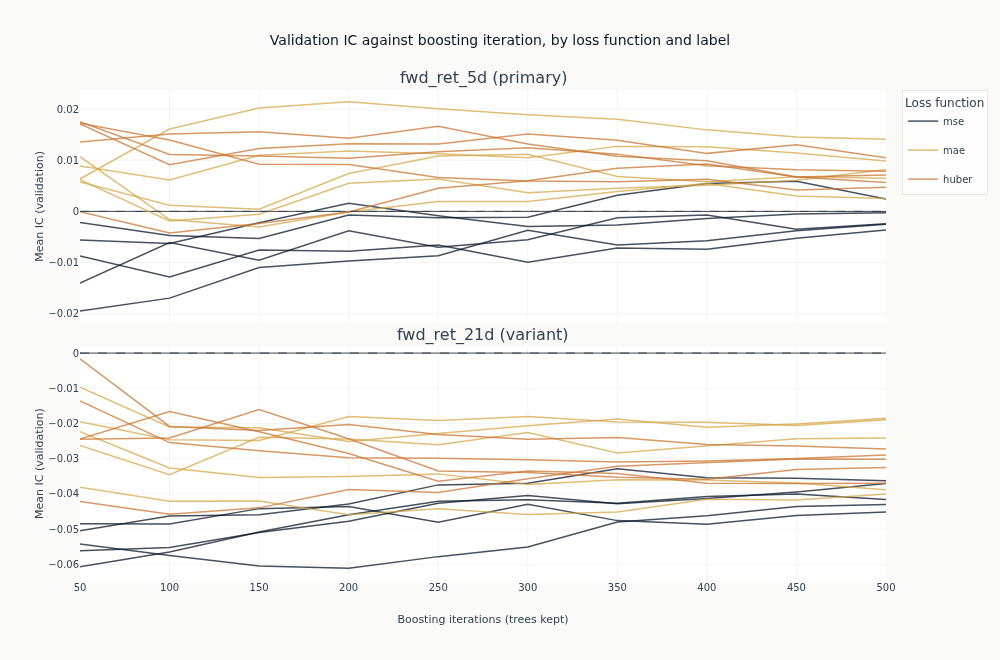

In [10]:
curves = catalog.filter("full_coverage").sort("label", "config_name", "checkpoint_value")
objectives = {"mse": COLORS["blue"], "mae": COLORS["amber"], "huber": COLORS["copper"]}


def objective_of(name: str) -> str:
    """Read the loss function out of a declared configuration name."""
    match = next((key for key in objectives if name.endswith(key)), None)
    if match is None:
        raise ValueError(f"{name!r} does not end in a declared objective: {sorted(objectives)}")
    return match


fig_curves = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = curves.filter(pl.col("label") == label)
    for objective, color in objectives.items():
        members = [
            name
            for name in panel.get_column("config_name").unique(maintain_order=True)
            if objective_of(name) == objective
        ]
        for index, config_name in enumerate(members):
            series = panel.filter(pl.col("config_name") == config_name)
            fig_curves.add_trace(
                go.Scatter(
                    x=series.get_column("checkpoint_value").to_list(),
                    y=series.get_column("ic_mean").to_list(),
                    mode="lines",
                    name=objective,
                    legendgroup=objective,
                    # One legend entry per loss function, not per configuration: the colour is
                    # the claim, and thirty named lines would bury it.
                    showlegend=row == 1 and index == 0,
                    line=dict(color=color, width=1.5),
                    opacity=0.75,
                ),
                row=row,
                col=1,
            )
    fig_curves.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_curves.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_curves.update_xaxes(title_text="Boosting iterations (trees kept)", row=len(panel_labels), col=1)
fig_curves.update_layout(
    title="Validation IC against boosting iteration, by loss function and label",
    height=330 * len(panel_labels),
    width=1000,
    margin=dict(t=90),
    legend=dict(title_text="Loss function"),
)
# How many lines dip below zero at some checkpoint is a fact about the frame, so the alt text
# reads it rather than asserting it: two five-day configurations touch a fraction of a thousandth
# below zero at their earliest checkpoints, and describing the panel as uniformly positive would
# be a claim the data refutes.
dip_text = " and ".join(
    f"{row['below']} of {row['total']} in the {row['label']} panel"
    for row in curves.group_by("label")
    .agg(
        total=pl.col("config_name").n_unique(),
        below=pl.col("config_name").filter(pl.col("ic_mean") < 0).n_unique(),
    )
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig_curves,
    "Line charts of mean validation information coefficient against boosting iteration, one line "
    "per configuration, coloured by loss function: dark navy for squared error, gold for absolute "
    "error, copper for Huber. Each panel carries a dashed zero line. The five-day panel sits "
    "almost entirely above that line, with the copper Huber lines running highest and the navy "
    "squared-error lines lowest; the 21-day panel sits below it, and its two lowest navy lines "
    "run near -0.04 throughout. Counted from the underlying frame, the lines that dip below zero "
    f"at some checkpoint are {dip_text}. The lines wander "
    "up and down rather than rising to a common peak and falling away, so no single stopping "
    "point stands out in either panel.",
)

Whether the lines trend, and which way, is not something to read off a page of overlapping
curves. The frame below measures it: for each configuration, its IC at the last checkpoint
minus its IC at the first, and whether its best checkpoint is an interior one rather than
either end. A family that is still learning would show positive changes and interior peaks; a
family that is overfitting would show negative changes; a family with nothing to learn would
show changes centred on zero with peaks scattered anywhere.

In [11]:
drift = (
    curves.group_by("label", "config_name")
    .agg(
        first_ic=pl.col("ic_mean").sort_by("checkpoint_value").first(),
        last_ic=pl.col("ic_mean").sort_by("checkpoint_value").last(),
        peak_checkpoint=pl.col("checkpoint_value").sort_by("ic_mean", descending=True).first(),
        first_checkpoint=pl.col("checkpoint_value").min(),
        last_checkpoint=pl.col("checkpoint_value").max(),
    )
    .with_columns(
        change=pl.col("last_ic") - pl.col("first_ic"),
        interior_peak=pl.col("peak_checkpoint").is_between(
            pl.col("first_checkpoint"), pl.col("last_checkpoint"), closed="none"
        ),
    )
)
trees_effect = (
    drift.group_by("label")
    .agg(
        configurations=pl.len(),
        median_change=pl.col("change").median(),
        ended_lower=(pl.col("change") < 0).sum(),
        interior_peaks=pl.col("interior_peak").sum(),
    )
    .sort("label")
)
trees_effect

label,configurations,median_change,ended_lower,interior_peaks
str,u32,f64,u32,u32
"""fwd_ret_21d""",15,0.000598,7,8
"""fwd_ret_5d""",15,0.002028,5,8


### Comparing every configuration at the same training length

The curves are coloured by objective because that is the axis with a mechanism behind it. If
heavy tails are steering the squared-error fits, the three colours should separate, and they
should separate more as trees are added, since each additional tree is fitted to the residuals
the previous ones left.

The chart below drops the checkpoint dimension by taking each configuration's final state, so
every configuration is compared at the same amount of training. That is the comparison that does
not require choosing anything after the fact. The configurations are held in one order across
the panels - their ranking on the primary label - so a panel that does not descend is a horizon
that orders the grid differently.

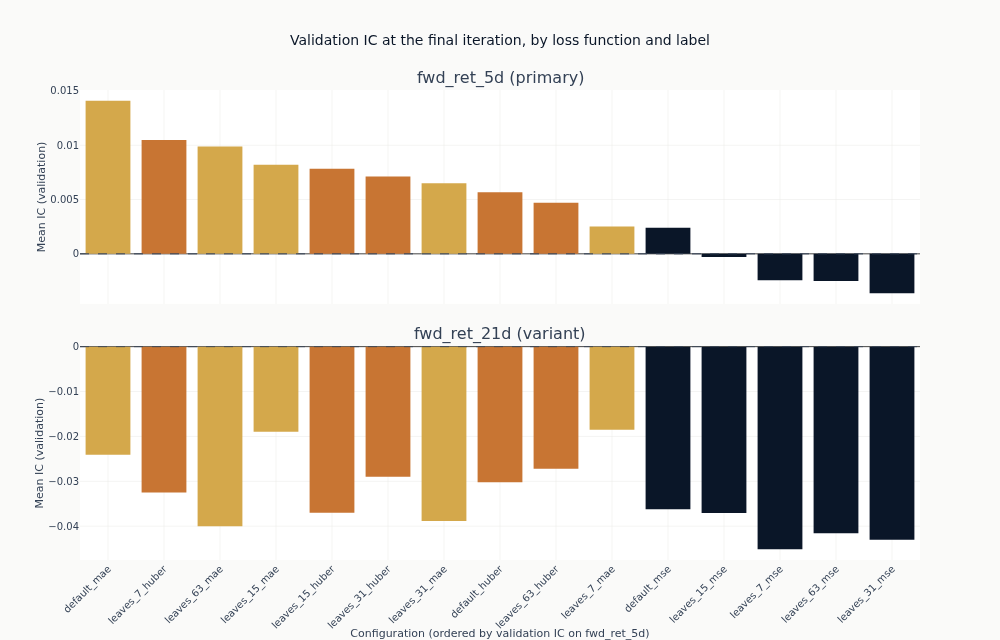

In [12]:
final = (
    catalog.filter(pl.col("checkpoint_value") == pl.col("checkpoint_value").max().over("label"))
    .filter("full_coverage")
    .with_columns(objective=pl.col("config_name").map_elements(objective_of, return_dtype=pl.Utf8))
    .sort(["label", "ic_mean"], descending=[False, True])
)
final_iteration = int(final.get_column("checkpoint_value").max())
config_order = (
    final.filter(pl.col("label") == order_label)
    .sort("ic_mean", descending=True)
    .get_column("config_name")
    .to_list()
)

fig_obj = make_subplots(
    rows=len(panel_labels),
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.09,
    subplot_titles=[
        f"{label} ({'primary' if label == primary else 'variant'})" for label in panel_labels
    ],
)
for row, label in enumerate(panel_labels, start=1):
    panel = final.filter(pl.col("label") == label)
    fig_obj.add_trace(
        go.Bar(
            x=panel.get_column("config_name").to_list(),
            y=panel.get_column("ic_mean").to_list(),
            marker_color=[objectives[value] for value in panel.get_column("objective")],
        ),
        row=row,
        col=1,
    )
    fig_obj.add_hline(
        y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"], row=row, col=1
    )
    fig_obj.update_yaxes(title_text="Mean IC (validation)", row=row, col=1)
fig_obj.update_xaxes(
    categoryorder="array",
    categoryarray=config_order,
    tickangle=-45,
    title_text=f"Configuration (ordered by validation IC on {order_label})",
    row=len(panel_labels),
    col=1,
)
fig_obj.update_layout(
    title="Validation IC at the final iteration, by loss function and label",
    height=320 * len(panel_labels),
    width=1000,
    showlegend=False,
    margin=dict(t=90),
)
show_plotly_with_alt(
    fig_obj,
    "Stacked bar charts of mean validation information coefficient at the final boosting "
    "iteration, coloured by loss function: dark navy for squared error, gold for absolute error, "
    "copper for Huber. The configurations are in the same order in each panel, that order being "
    f"their ranking on {order_label}, and each panel carries a dashed zero line. Every bar in the "
    "five-day panel rises above the line, from 0.026 down to 0.006, led by four copper Huber bars "
    "and a gold one. Every bar in the 21-day panel hangs below it, and the two longest there are "
    "navy squared-error bars near -0.042 that sit seventh and thirteenth in the panel above.",
)

### Whether the horizon does here what it did to the linear grid

The question this notebook took from `06_linear`, answered at the same training length for
every configuration. There the best full-coverage IC and the count above zero both rose sharply
with the horizon, and every configuration that cleared zero was an L1 fit; the frame below says
whether a tree ensemble reproduces that.

In [13]:
horizons = (
    final.group_by("label")
    .agg(
        configurations=pl.len(),
        best_ic=pl.col("ic_mean").max(),
        worst_ic=pl.col("ic_mean").min(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort("label")
)
horizons

label,configurations,best_ic,worst_ic,above_zero
str,u32,f64,f64,u32
"""fwd_ret_21d""",15,-0.018537,-0.045147,0
"""fwd_ret_5d""",15,0.014104,-0.003621,11


### Whether the loss function separates them

The colours in the chart above are the claim, so here is the claim as numbers: at the final
iteration, each loss function's mean IC and how many of its configurations finished above zero,
per label. The ordering the heavy-tailed case studies show is Huber highest, absolute error
next, squared error lowest.

In [14]:
objective_summary = (
    final.group_by("label", "objective")
    .agg(
        configurations=pl.len(),
        mean_ic=pl.col("ic_mean").mean(),
        best_ic=pl.col("ic_mean").max(),
        above_zero=(pl.col("ic_mean") > 0).sum(),
    )
    .sort(["label", "mean_ic"], descending=[False, True])
)
objective_summary

label,objective,configurations,mean_ic,best_ic,above_zero
str,str,u32,f64,f64,u32
"""fwd_ret_21d""","""mae""",5,-0.028084,-0.018537,0
"""fwd_ret_21d""","""huber""",5,-0.031171,-0.02722,0
"""fwd_ret_21d""","""mse""",5,-0.040612,-0.03624,0
"""fwd_ret_5d""","""mae""",5,0.008243,0.014104,5
"""fwd_ret_5d""","""huber""",5,0.007167,0.01049,5
"""fwd_ret_5d""","""mse""",5,-0.001291,0.002403,1


### What the tails of each label look like

The usual explanation for a loss function changing a rank measure is the tail of the label. A
squared-error fit weights a residual by its square, so one extreme observation moves the fit
more than many ordinary ones; absolute error and Huber do not, and a rank measure does not
reward chasing the extreme. Where that mechanism is at work, the ordering Huber, absolute
error, squared error should be clearest on the heavier-tailed label.

Excess kurtosis is the direct measurement of that, so it is worth taking before the explanation
is applied rather than after. Zero is the normal distribution; larger means more of the
variance sits in rare large moves.

The label artifact on disk runs to the end of the data, holdout included. Measuring across all
of it would put a statistic computed partly on sealed outcomes into a validation-stage
notebook, so each label's rows are cut at its own `validation_end` - the same development
boundary its fits were resolved against, taken from the plan rather than re-derived.

The artifact is asked for at the tier this notebook is running, rather than at the default.
`LabelCatalog.get` activates the tier it is given before resolving, and a preview activates a
workspace that carries `labels` as a link while its canonical root is empty - so a diagnostic
cell that takes the default reads a path only a canonical run has, and fails in preview after
the fits it is describing have already succeeded.

In [15]:
# Each label has its own development boundary, because a longer forward window has to stop
# earlier to keep its outcome inside the development period. One global maximum would cut the
# 21-day label at the five-day label's date and leave decision dates whose forward window ends
# inside the holdout.
development_end = dict(plan.group_by("label").agg(pl.col("validation_end").max()).iter_rows())
tails = pl.DataFrame(
    [
        {
            "label": label,
            "development_end": development_end[label],
            "rows": measured.height,
            "excess_kurtosis": measured.get_column(label).kurtosis(),
        }
        for label in panel_labels
        for measured in [
            pl.read_parquet(study.labels.get(label, execution_tier=EXECUTION_TIER).path)
            .filter(pl.col("timestamp") <= development_end[label])
            .drop_nulls(label)
        ]
    ]
)
tails

label,development_end,rows,excess_kurtosis
str,date,i64,f64
"""fwd_ret_5d""",2023-12-21,97921,22.723696
"""fwd_ret_21d""",2023-11-29,97393,18.663213


### How much the checkpoint moves a configuration

One number per configuration and label: the range its IC covers across its own ten checkpoints.
This is the quantity that decides whether choosing a stopping point is a decision worth making
carefully or one being made by noise. A configuration whose IC varies more across its own
training run than the configurations vary among themselves is one where the checkpoint, not the
model, is doing the ranking.

The frame below reduces that to one comparison per label: how far the fifteen configurations
spread at a fixed training length, against how far the median configuration travels across its
own checkpoints. A ratio near one means the two decisions are the same size, and choosing a
checkpoint is as consequential as choosing a model. The five widest-ranging configurations at
each label follow it.

In [16]:
spread = (
    curves.group_by("label", "config_name")
    .agg(
        ic_min=pl.col("ic_mean").min(),
        ic_max=pl.col("ic_mean").max(),
        ic_final=pl.col("ic_mean").filter(pl.col("checkpoint_value") == final_iteration).first(),
    )
    .with_columns(checkpoint_range=pl.col("ic_max") - pl.col("ic_min"))
    .sort(["label", "checkpoint_range"], descending=[False, True])
)
comparison = (
    final.group_by("label")
    .agg(across_configurations=pl.col("ic_mean").max() - pl.col("ic_mean").min())
    .join(
        spread.group_by("label").agg(within_one_configuration=pl.col("checkpoint_range").median()),
        on="label",
    )
    .with_columns(ratio=pl.col("across_configurations") / pl.col("within_one_configuration"))
    .sort("label")
)
comparison

label,across_configurations,within_one_configuration,ratio
str,f64,f64,f64
"""fwd_ret_21d""",0.02661,0.017345,1.534144
"""fwd_ret_5d""",0.017725,0.01076,1.64728


In [17]:
spread.group_by("label", maintain_order=True).head(5)

label,config_name,ic_min,ic_max,ic_final,checkpoint_range
str,str,f64,f64,f64,f64
"""fwd_ret_21d""","""leaves_63_huber""",-0.02722,-0.001646,-0.02722,0.025575
"""fwd_ret_21d""","""leaves_63_mse""",-0.060676,-0.040048,-0.041585,0.020628
"""fwd_ret_21d""","""leaves_15_huber""",-0.037025,-0.016584,-0.036976,0.02044
"""fwd_ret_21d""","""leaves_7_huber""",-0.035841,-0.016055,-0.032511,0.019786
"""fwd_ret_21d""","""leaves_15_mse""",-0.056166,-0.037068,-0.037068,0.019098
"""fwd_ret_5d""","""leaves_63_mse""",-0.019512,-0.002508,-0.002508,0.017004
"""fwd_ret_5d""","""default_mae""",0.006341,0.021474,0.014104,0.015133
"""fwd_ret_5d""","""leaves_7_mae""",-0.003048,0.010696,0.002522,0.013745
"""fwd_ret_5d""","""default_huber""",-0.00421,0.009292,0.005672,0.013502


## 5. What to notice

**At the traded horizon every configuration ranks the cross-section the right way, which the
linear grid did not.** Every five-day configuration is positive at the end of training - read
`above_zero` against `configurations` in the horizons frame - and the weakest of them is a
multiple of the leading full-coverage linear result at that horizon. Something in this data
is available to a model that can split on one
feature inside a region defined by another, and is not available to a weighted sum of the
columns. The two hand-built interaction terms in the feature set, `carry_mom_composite` and
`carry_mom_interaction`, exist because someone had to name that structure for the linear model;
the trees are finding more of it than was named.

**The horizons reverse between the two families, which is what fitting both labels here was
for.** The linear grid did better at 21 days than at five - by how much depends on how the
coverage filter is handled, and `06_linear` works that through - while this grid does the
opposite outright: every five-day configuration above zero, and *nothing* above zero at 21,
where `best_ic` and `worst_ic` in the horizons frame are both negative. The direction of the
reversal
does not depend on any of the qualifications the linear comparison needs, which is what makes
it the durable finding here. What each family can represent decides which horizon it reads. So
neither notebook's horizon ranking carries into the other, and the strong-L1 advantage at 21
days in the linear notebook is a fact about that family on that label rather than about the
label.

It does not follow that five days is the better horizon. The two labels are fitted under
different purge buffers, so they resolve different folds and different samples, and a
comparison across them is between two label-specific protocols. What is being compared cleanly
is the two *families* on each label, and there the answer is unambiguous at both.

**Squared error is last at both horizons; the rest of the ordering is not stable.** At five
days the objective frame gives the textbook ordering - Huber, then absolute error, then
squared error - and at 21 days absolute error and Huber swap while squared error stays
clearly last. The mechanism usually offered is the label's tails: squared error
weights an observation by the square of its error, so the largest commodity moves dominate what
each successive tree is fitted to, while a rank correlation cares about order rather than
magnitude, and effort spent getting the extremes right buys nothing on this metric. The tails
frame is consistent with that as far as it goes - the five-day label carries the heavier excess
kurtosis of the two, and the clean ordering is on the heavier one - but the two kurtoses are
close enough that this is one observation and not a demonstration. What the two labels do
establish is the part
that did not move: **an objective is a claim about which errors matter, and squared error is the
wrong claim when the result is judged on ranks.**

**The checkpoint moves the answer within a small factor of what the model does.** The
`comparison` frame puts the spread across the configurations against the median
configuration's own checkpoint range at each horizon, and the ratio is a small multiple at
both. So the stopping point is not a detail: it is a second dial of the same order as the
first. Adding trees does not settle it either - the median configuration ends near where it
started at both horizons, a substantial share end lower, and the best checkpoint is an
interior one for most configurations at 21 days. There is no common turning point to read
off, which is why the comparison that holds is the fixed-iteration chart rather than each
configuration's best moment. Reporting the leading row of the table would be reporting the
maximum of every candidate as though it were one.

**The capacity axis does not produce the textbook shape.** The usual reason to sweep leaf count
is to find where out-of-sample performance turns over, and here it does not turn over cleanly:
the deepest and shallowest settings both appear near the top and near the bottom depending on
the objective they are paired with, at both horizons. Capacity and loss interact, and a
one-dimensional reading of either axis on its own will find a pattern that the other axis
explains.

**None of this selects anything.** IC measures whether predictions rank products correctly, not
whether a strategy trading them makes money after costs and turnover. A few hundredths of rank
correlation is not by itself a tradeable edge, and turnover on a five-day horizon is exactly
where a small ranking advantage is lost. Selection is on validation backtest Sharpe over the population just
published, and it happens in [`13_backtest`](13_backtest.ipynb), where the checkpoint is part of
what is selected.

**Known limitations.** The IC is an average of daily rank correlations with no adjustment for
the serial dependence overlapping returns create, so it is a diagnostic rather than a test, and
it does not carry an interval that would say whether these configurations differ from each
other. Thirty products is a narrow cross-section for a daily rank correlation. The grid varies
capacity and loss at a fixed learning rate and a fixed tree count, so it says nothing about
trading one against another. And every number here is measured on validation folds that have
been read many times over by the time a case study reaches this notebook.

**Next**: [`08_tabular_dl`](08_tabular_dl.ipynb) asks the same question of a neural network
built for tabular data, which represents interactions in a third way again. The useful thing to
watch there is whether it recovers the same structure the trees found, and which horizon it
reads - a third family with a third answer would say the horizon ranking is a fact about
representation rather than about the data.